# Kuber Budhathoki
# s399136
# foundation of datascience
# assignment2 -  objective 1
# analytical question : 
Analytical Question choosen :
> Is there a statistically significant difference in the average goals conceded per match ($GA / MP$) between UEFA (European) teams and CONMEBOL (South American) teams during the FIFA World Cup 2026?

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [46]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 10

In [47]:
from pathlib import Path

# Support kernels launched from this topic folder or the repository root.
TOPIC = Path.cwd()
if not (TOPIC / "data" / "data.csv").is_file():
    TOPIC = TOPIC / "topics" / "04_goals_conceded_by_confederation"
DATA = TOPIC / "data"
OUTPUTS = TOPIC / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

# Load the dataset - data set is downloaded from https://fbref.com/en/ and save as data.csv
df_raw = pd.read_csv(DATA / "data.csv")
print("Raw Dataset Shape:", df_raw.shape)

Raw Dataset Shape: (48, 13)


In [48]:
df_raw.head()

,Rk,Squad,MP,W,D,L,GF,GA,GD,Pts,Top Team Scorer,Goalkeeper,Notes
0,1,es Spain,8,7,1,0,14,1,13,22,Mikel Oyarzabal - 5,Unai Simón,NaN
1,2,ar Argentina,8,7,0,1,19,8,11,21,Lionel Messi - 8,Emiliano Martínez,NaN
2,3,eng England,8,6,1,1,20,12,8,19,Jude Bellingham - 7,Jordan Pickford,NaN
3,4,fr France,8,6,0,2,20,10,10,18,Kylian Mbappé - 10,Mike Maignan,NaN
4,QF,no Norway,6,4,0,2,13,11,2,12,Erling Haaland - 7,Ørjan Nyland,NaN


In [49]:
df_raw.columns

Index(['Rk', 'Squad', 'MP', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'Pts',
       'Top Team Scorer', 'Goalkeeper', 'Notes'],
      dtype='str')

Analytical Question choosen :
> Is there a statistically significant difference in the average goals conceded per match ($GA / MP$) between UEFA (European) teams and CONMEBOL (South American) teams during the FIFA World Cup 2026?

For the purpose of classifying the team to conmebol and european , i hard code the team to either UefA or comebol

In [50]:

# Explicit mapping for UEFA and CONMEBOL member associations
confederation_mapping = {
    "es Spain": "UEFA",
    "eng England": "UEFA",
    "fr France": "UEFA",
    "no Norway": "UEFA",
    "be Belgium": "UEFA",
    "ch Switzerland": "UEFA",
    "pt Portugal": "UEFA",
    "nl Netherlands": "UEFA",
    "de Germany": "UEFA",
    "hr Croatia": "UEFA",
    "se Sweden": "UEFA",
    "at Austria": "UEFA",
    "ba Bosnia–Herz": "UEFA",
    "tr Türkiye": "UEFA",
    "sct Scotland": "UEFA",
    "cz Czechia": "UEFA",
    "ar Argentina": "CONMEBOL",
    "co Colombia": "CONMEBOL",
    "br Brazil": "CONMEBOL",
    "py Paraguay": "CONMEBOL",
    "ec Ecuador": "CONMEBOL",
    "uy Uruguay": "CONMEBOL",
}

In [51]:
# Assign confederations to the dataframe columns called "Confederation" based on the mapping 
df_raw["Confederation"] = df_raw["Squad"].map(confederation_mapping)

# ONly keep rows where the "Confederation" column is in the mapping values (UEFA or CONMEBOL)
# Filter for UEFA and CONMEBOL teams
df = df_raw[df_raw["Confederation"].isin(["UEFA", "CONMEBOL"])].copy()


In [52]:
df.head()

,Rk,Squad,MP,W,D,L,GF,GA,GD,Pts,Top Team Scorer,Goalkeeper,Notes,Confederation
0,1,es Spain,8,7,1,0,14,1,13,22,Mikel Oyarzabal - 5,Unai Simón,NaN,UEFA
1,2,ar Argentina,8,7,0,1,19,8,11,21,Lionel Messi - 8,Emiliano Martínez,NaN,CONMEBOL
2,3,eng England,8,6,1,1,20,12,8,19,Jude Bellingham - 7,Jordan Pickford,NaN,UEFA
3,4,fr France,8,6,0,2,20,10,10,18,Kylian Mbappé - 10,Mike Maignan,NaN,UEFA
4,QF,no Norway,6,4,0,2,13,11,2,12,Erling Haaland - 7,Ørjan Nyland,NaN,UEFA


In [53]:

# Feature Engineering: Normalized Goals Conceded per Match
df["GA_per_MP"] = df["GA"] / df["MP"]

# Display wrangled dataframe summary
df[["Squad", "Confederation", "MP", "GA", "GA_per_MP"]].head()

,Squad,Confederation,MP,GA,GA_per_MP
0,es Spain,UEFA,8,1,0.125000
1,ar Argentina,CONMEBOL,8,8,1.000000
2,eng England,UEFA,8,12,1.500000
3,fr France,UEFA,8,10,1.250000
4,no Norway,UEFA,6,11,1.833333


In [54]:
# Separate into stratified samples
uefa_sample = df[df["Confederation"] == "UEFA"]["GA_per_MP"]
conmebol_sample = df[df["Confederation"] == "CONMEBOL"]["GA_per_MP"]


In [55]:
print("UEFA Sample Statistics:")
print(uefa_sample.describe())
print("\nCONMEBOL Sample Statistics:")
print(conmebol_sample.describe())

UEFA Sample Statistics:
count    16.000000
mean      1.467188
std       0.606832
min       0.125000
25%       1.229167
50%       1.416667
75%       1.875000
max       2.500000
Name: GA_per_MP, dtype: float64

CONMEBOL Sample Statistics:
count    6.000000
mean     0.922222
std      0.398702
min      0.200000
25%      0.850000
50%      1.000000
75%      1.150000
max      1.333333
Name: GA_per_MP, dtype: float64


In [56]:
print(uefa_sample.head())

0    0.125000
2    1.500000
3    1.250000
4    1.833333
5    1.166667
Name: GA_per_MP, dtype: float64


In [57]:
# Compute key descriptive summary
desc_stats = (
    df.groupby("Confederation")["GA_per_MP"]
    .agg(
        Count="count",
        Mean="mean",
        Std_Dev="std",
        Median="median",
        Min="min",
        Max="max",
        IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
    )
    .reset_index()
)

print("Descriptive Statistics Table:")
print(desc_stats.to_string(index=False))

Descriptive Statistics Table:
Confederation  Count     Mean  Std_Dev   Median   Min      Max      IQR
     CONMEBOL      6 0.922222 0.398702 1.000000 0.200 1.333333 0.300000
         UEFA     16 1.467188 0.606832 1.416667 0.125 2.500000 0.645833


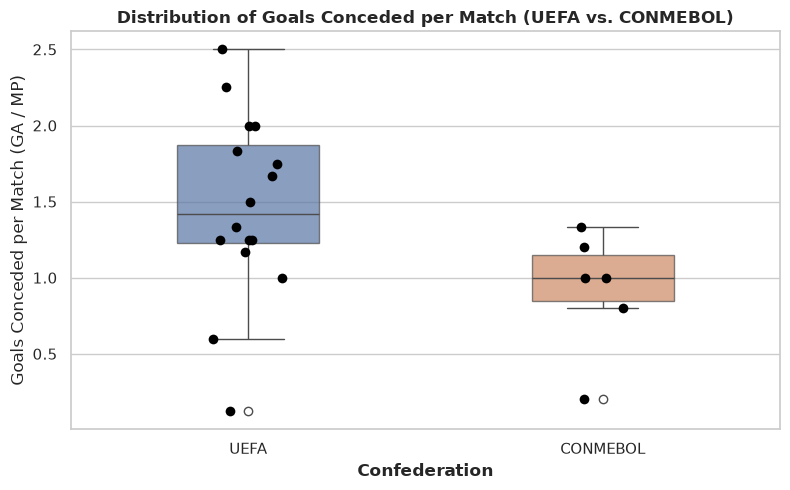

In [58]:
# Comparative Boxplot and Strip Plot
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Confederation",
    y="GA_per_MP",
    hue="Confederation",
    width=0.4,
    boxprops=dict(alpha=0.7),
)
sns.stripplot(
    data=df,
    x="Confederation",
    y="GA_per_MP",
    color="black",
    size=7,
    jitter=0.1,
)
plt.title(
    "Distribution of Goals Conceded per Match (UEFA vs. CONMEBOL)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Confederation", fontweight="bold")
plt.ylabel("Goals Conceded per Match (GA / MP)")
plt.tight_layout()
plt.savefig(OUTPUTS / "figure_01.png", dpi=200, bbox_inches="tight")
plt.show()

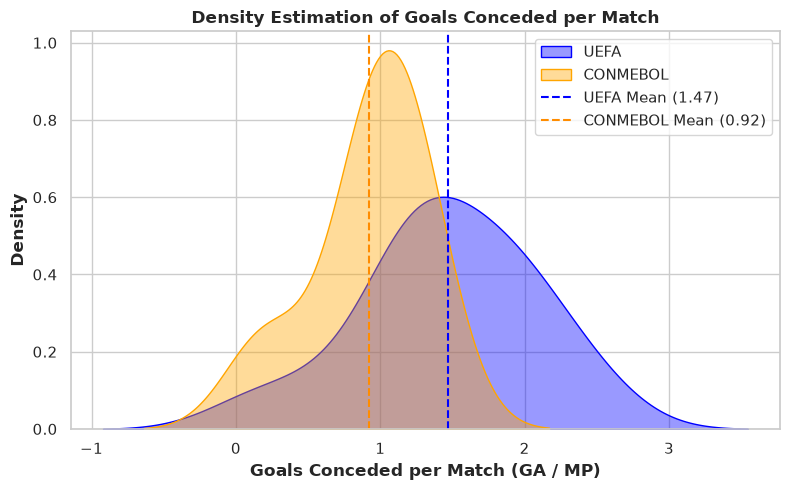

In [59]:
# Distribution KDE Plots
plt.figure(figsize=(8, 5))
sns.kdeplot(
    uefa_sample,
    label="UEFA",
    fill=True,
    alpha=0.4,
    color="blue",
    common_norm=False,
)
sns.kdeplot(
    conmebol_sample,
    label="CONMEBOL",
    fill=True,
    alpha=0.4,
    color="orange",
    common_norm=False,
)
plt.axvline(
    uefa_sample.mean(),
    color="blue",
    linestyle="--",
    label=f"UEFA Mean ({uefa_sample.mean():.2f})",
)
plt.axvline(
    conmebol_sample.mean(),
    color="darkorange",
    linestyle="--",
    label=f"CONMEBOL Mean ({conmebol_sample.mean():.2f})",
)
plt.title(
    "Density Estimation of Goals Conceded per Match",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Goals Conceded per Match (GA / MP)", fontweight="bold")
plt.ylabel("Density", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "figure_02.png", dpi=200, bbox_inches="tight")
plt.show()

In [60]:
# Sample parameters
m1, m2 = uefa_sample.mean(), conmebol_sample.mean()
v1, v2 = uefa_sample.var(ddof=1), conmebol_sample.var(ddof=1)
n1, n2 = len(uefa_sample), len(conmebol_sample)

# Point estimate difference
diff_mean = m1 - m2

# Standard error of the difference
se_diff = np.sqrt((v1 / n1) + (v2 / n2))

# Welch-Satterthwaite degrees of freedom
dof = ((v1 / n1) + (v2 / n2)) ** 2 / (
    ((v1 / n1) ** 2 / (n1 - 1)) + ((v2 / n2) ** 2 / (n2 - 1))
)

# 95% Confidence Interval calculation
t_critical = stats.t.ppf(0.975, df=dof)
ci_lower = diff_mean - (t_critical * se_diff)
ci_upper = diff_mean + (t_critical * se_diff)

print(f"Mean Difference (UEFA - CONMEBOL): {diff_mean:.4f}")
print(f"Standard Error: {se_diff:.4f}")
print(f"Degrees of Freedom: {dof:.2f}")
print(f"95% Confidence Interval for Difference: ({ci_lower:.4f}, {ci_upper:.4f})")

Mean Difference (UEFA - CONMEBOL): 0.5450
Standard Error: 0.2225
Degrees of Freedom: 13.95
95% Confidence Interval for Difference: (0.0676, 1.0224)


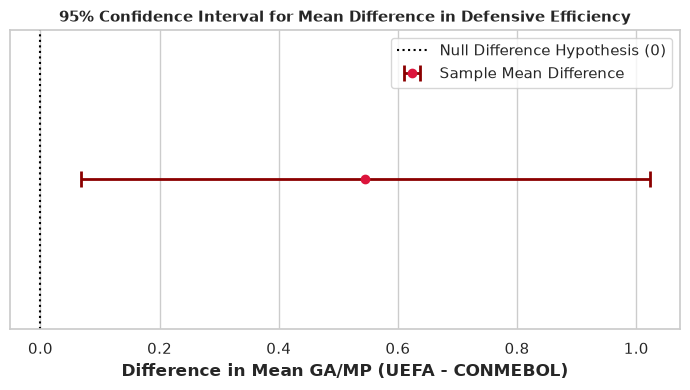

In [61]:
# Confidence Interval Plot (Corrected)
plt.figure(figsize=(7, 4))
plt.errorbar(
    x=[diff_mean],
    y=[0],
    xerr=[[diff_mean - ci_lower], [ci_upper - diff_mean]],
    fmt="o",
    color="crimson",
    ecolor="darkred",
    linewidth=2,  # Replaced 'elv=3' with 'linewidth=2'
    capsize=6,
    capthick=2,
    label="Sample Mean Difference",
)
plt.axvline(
    0,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label="Null Difference Hypothesis (0)",
)
plt.yticks([])
plt.xlabel("Difference in Mean GA/MP (UEFA - CONMEBOL)", fontweight="bold")
plt.title(
    "95% Confidence Interval for Mean Difference in Defensive Efficiency",
    fontsize=11,
    fontweight="bold",
)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "figure_03.png", dpi=200, bbox_inches="tight")
plt.show()

Null Hypothesis ($H_0$): $\mu_{UEFA} = \mu_{CONMEBOL}$ (No difference in mean goals conceded per match between UEFA and CONMEBOL teams).Alternative Hypothesis ($H_1$): $\mu_{UEFA} \neq \mu_{CONMEBOL}$ (A significant difference exists in mean goals conceded per match).Significance Level ($\alpha$): 0.05

In [62]:
# Conduct Welch's Two-Sample t-Test
t_stat, p_val = stats.ttest_ind(uefa_sample, conmebol_sample, equal_var=False)

print("--- Welch's Two-Sample t-Test Results ---")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")
print(f"Degrees of Freedom: {dof:.2f}")

# Decision rule evaluation
alpha = 0.05
if p_val < alpha:
    print(
        f"Result: Reject the Null Hypothesis (p < {alpha}). There is a statistically significant difference in goals conceded per match between UEFA and CONMEBOL."
    )
else:
    print(
        f"Result: Fail to Reject the Null Hypothesis (p >= {alpha}). No statistically significant difference was detected."
    )

--- Welch's Two-Sample t-Test Results ---
t-statistic: 2.4492
p-value: 0.0281
Degrees of Freedom: 13.95
Result: Reject the Null Hypothesis (p < 0.05). There is a statistically significant difference in goals conceded per match between UEFA and CONMEBOL.


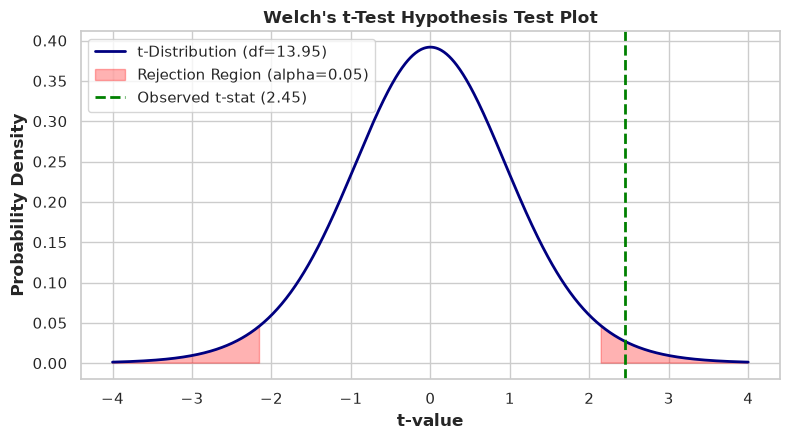

In [63]:
# Sampling Distribution & Critical Region Visualization
x_vals = np.linspace(-4, 4, 1000)
y_vals = stats.t.pdf(x_vals, df=dof)

plt.figure(figsize=(8, 4.5))
plt.plot(
    x_vals, y_vals, label=f"t-Distribution (df={dof:.2f})", color="navy", lw=2
)

# Critical regions
t_crit = stats.t.ppf(0.975, df=dof)
plt.fill_between(
    x_vals,
    0,
    y_vals,
    where=(x_vals >= t_crit) | (x_vals <= -t_crit),
    color="red",
    alpha=0.3,
    label="Rejection Region (alpha=0.05)",
)
plt.axvline(
    t_stat,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Observed t-stat ({t_stat:.2f})",
)

plt.title(
    "Welch's t-Test Hypothesis Test Plot", fontsize=12, fontweight="bold"
)
plt.xlabel("t-value", fontweight="bold")
plt.ylabel("Probability Density", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "figure_04.png", dpi=200, bbox_inches="tight")
plt.show()